<h1>Import Packages

In [38]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import itertools
import optuna
import time
import sklearn
from sklearn import tree
from sklearn.tree import export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

print(f'scikit-learn version: {sklearn.__version__}')


scikit-learn version: 1.2.1


<h1>Exploratory Data Analysis</h1>

In [39]:
train_df = pd.read_csv('~/Desktop/Vigil/datasets/Train_data.csv')
test_df = pd.read_csv('~/Desktop/Vigil/datasets/Test_data.csv')
train_df

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25187,0,tcp,exec,RSTO,0,0,0,0,0,0,...,7,0.03,0.06,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25188,0,tcp,ftp_data,SF,334,0,0,0,0,0,...,39,1.00,0.00,1.00,0.18,0.00,0.00,0.00,0.00,anomaly
25189,0,tcp,private,REJ,0,0,0,0,0,0,...,13,0.05,0.07,0.00,0.00,0.00,0.00,1.00,1.00,anomaly
25190,0,tcp,nnsp,S0,0,0,0,0,0,0,...,20,0.08,0.06,0.00,0.00,1.00,1.00,0.00,0.00,anomaly


In [40]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25192 entries, 0 to 25191
Data columns (total 42 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   duration                     25192 non-null  int64  
 1   protocol_type                25192 non-null  object 
 2   service                      25192 non-null  object 
 3   flag                         25192 non-null  object 
 4   src_bytes                    25192 non-null  int64  
 5   dst_bytes                    25192 non-null  int64  
 6   land                         25192 non-null  int64  
 7   wrong_fragment               25192 non-null  int64  
 8   urgent                       25192 non-null  int64  
 9   hot                          25192 non-null  int64  
 10  num_failed_logins            25192 non-null  int64  
 11  logged_in                    25192 non-null  int64  
 12  num_compromised              25192 non-null  int64  
 13  root_shell      

In [41]:
train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,anomaly
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [42]:
train_df.describe()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
count,25192.000000,2.519200e+04,2.519200e+04,25192.000000,25192.000000,25192.00000,25192.000000,25192.000000,25192.000000,25192.000000,...,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000,25192.000000
mean,305.054104,2.433063e+04,3.491847e+03,0.000079,0.023738,0.00004,0.198039,0.001191,0.394768,0.227850,...,182.532074,115.063036,0.519791,0.082539,0.147453,0.031844,0.285800,0.279846,0.117800,0.118769
std,2686.555640,2.410805e+06,8.883072e+04,0.008910,0.260221,0.00630,2.154202,0.045418,0.488811,10.417352,...,98.993895,110.646850,0.448944,0.187191,0.308367,0.110575,0.445316,0.446075,0.305869,0.317333
min,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,84.000000,10.000000,0.050000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,4.400000e+01,0.000000e+00,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,255.000000,61.000000,0.510000,0.030000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,2.790000e+02,5.302500e+02,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,...,255.000000,255.000000,1.000000,0.070000,0.060000,0.020000,1.000000,1.000000,0.000000,0.000000
max,42862.000000,3.817091e+08,5.151385e+06,1.000000,3.000000,1.00000,77.000000,4.000000,1.000000,884.000000,...,255.000000,255.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [43]:
train_df.describe(include='object')

,protocol_type,service,flag,class
count,25192,25192,25192,25192
unique,3,66,11,2
top,tcp,http,SF,normal
freq,20526,8003,14973,13449


In [44]:
train_df['class'].value_counts()

class
normal     13449
anomaly    11743
Name: count, dtype: int64

In [45]:
total_frame = train_df.shape[0]
miss_columns = [col for col in train_df.columns if train_df[col].isnull().sum() > 0] # Creating array of columns with null values
for col in miss_columns:
    null_count = train_df[col].isnull().sum()
    per = (null_count/total_frame) * 100
    print(f"{col}: {null_count} ({round(per, 3)}%)")

No missing values within dataset.

In [46]:
print(f"Number of duplicates: {train_df.duplicated().sum()}")

Number of duplicates: 0


No duplicates within dataset.

<Axes: >

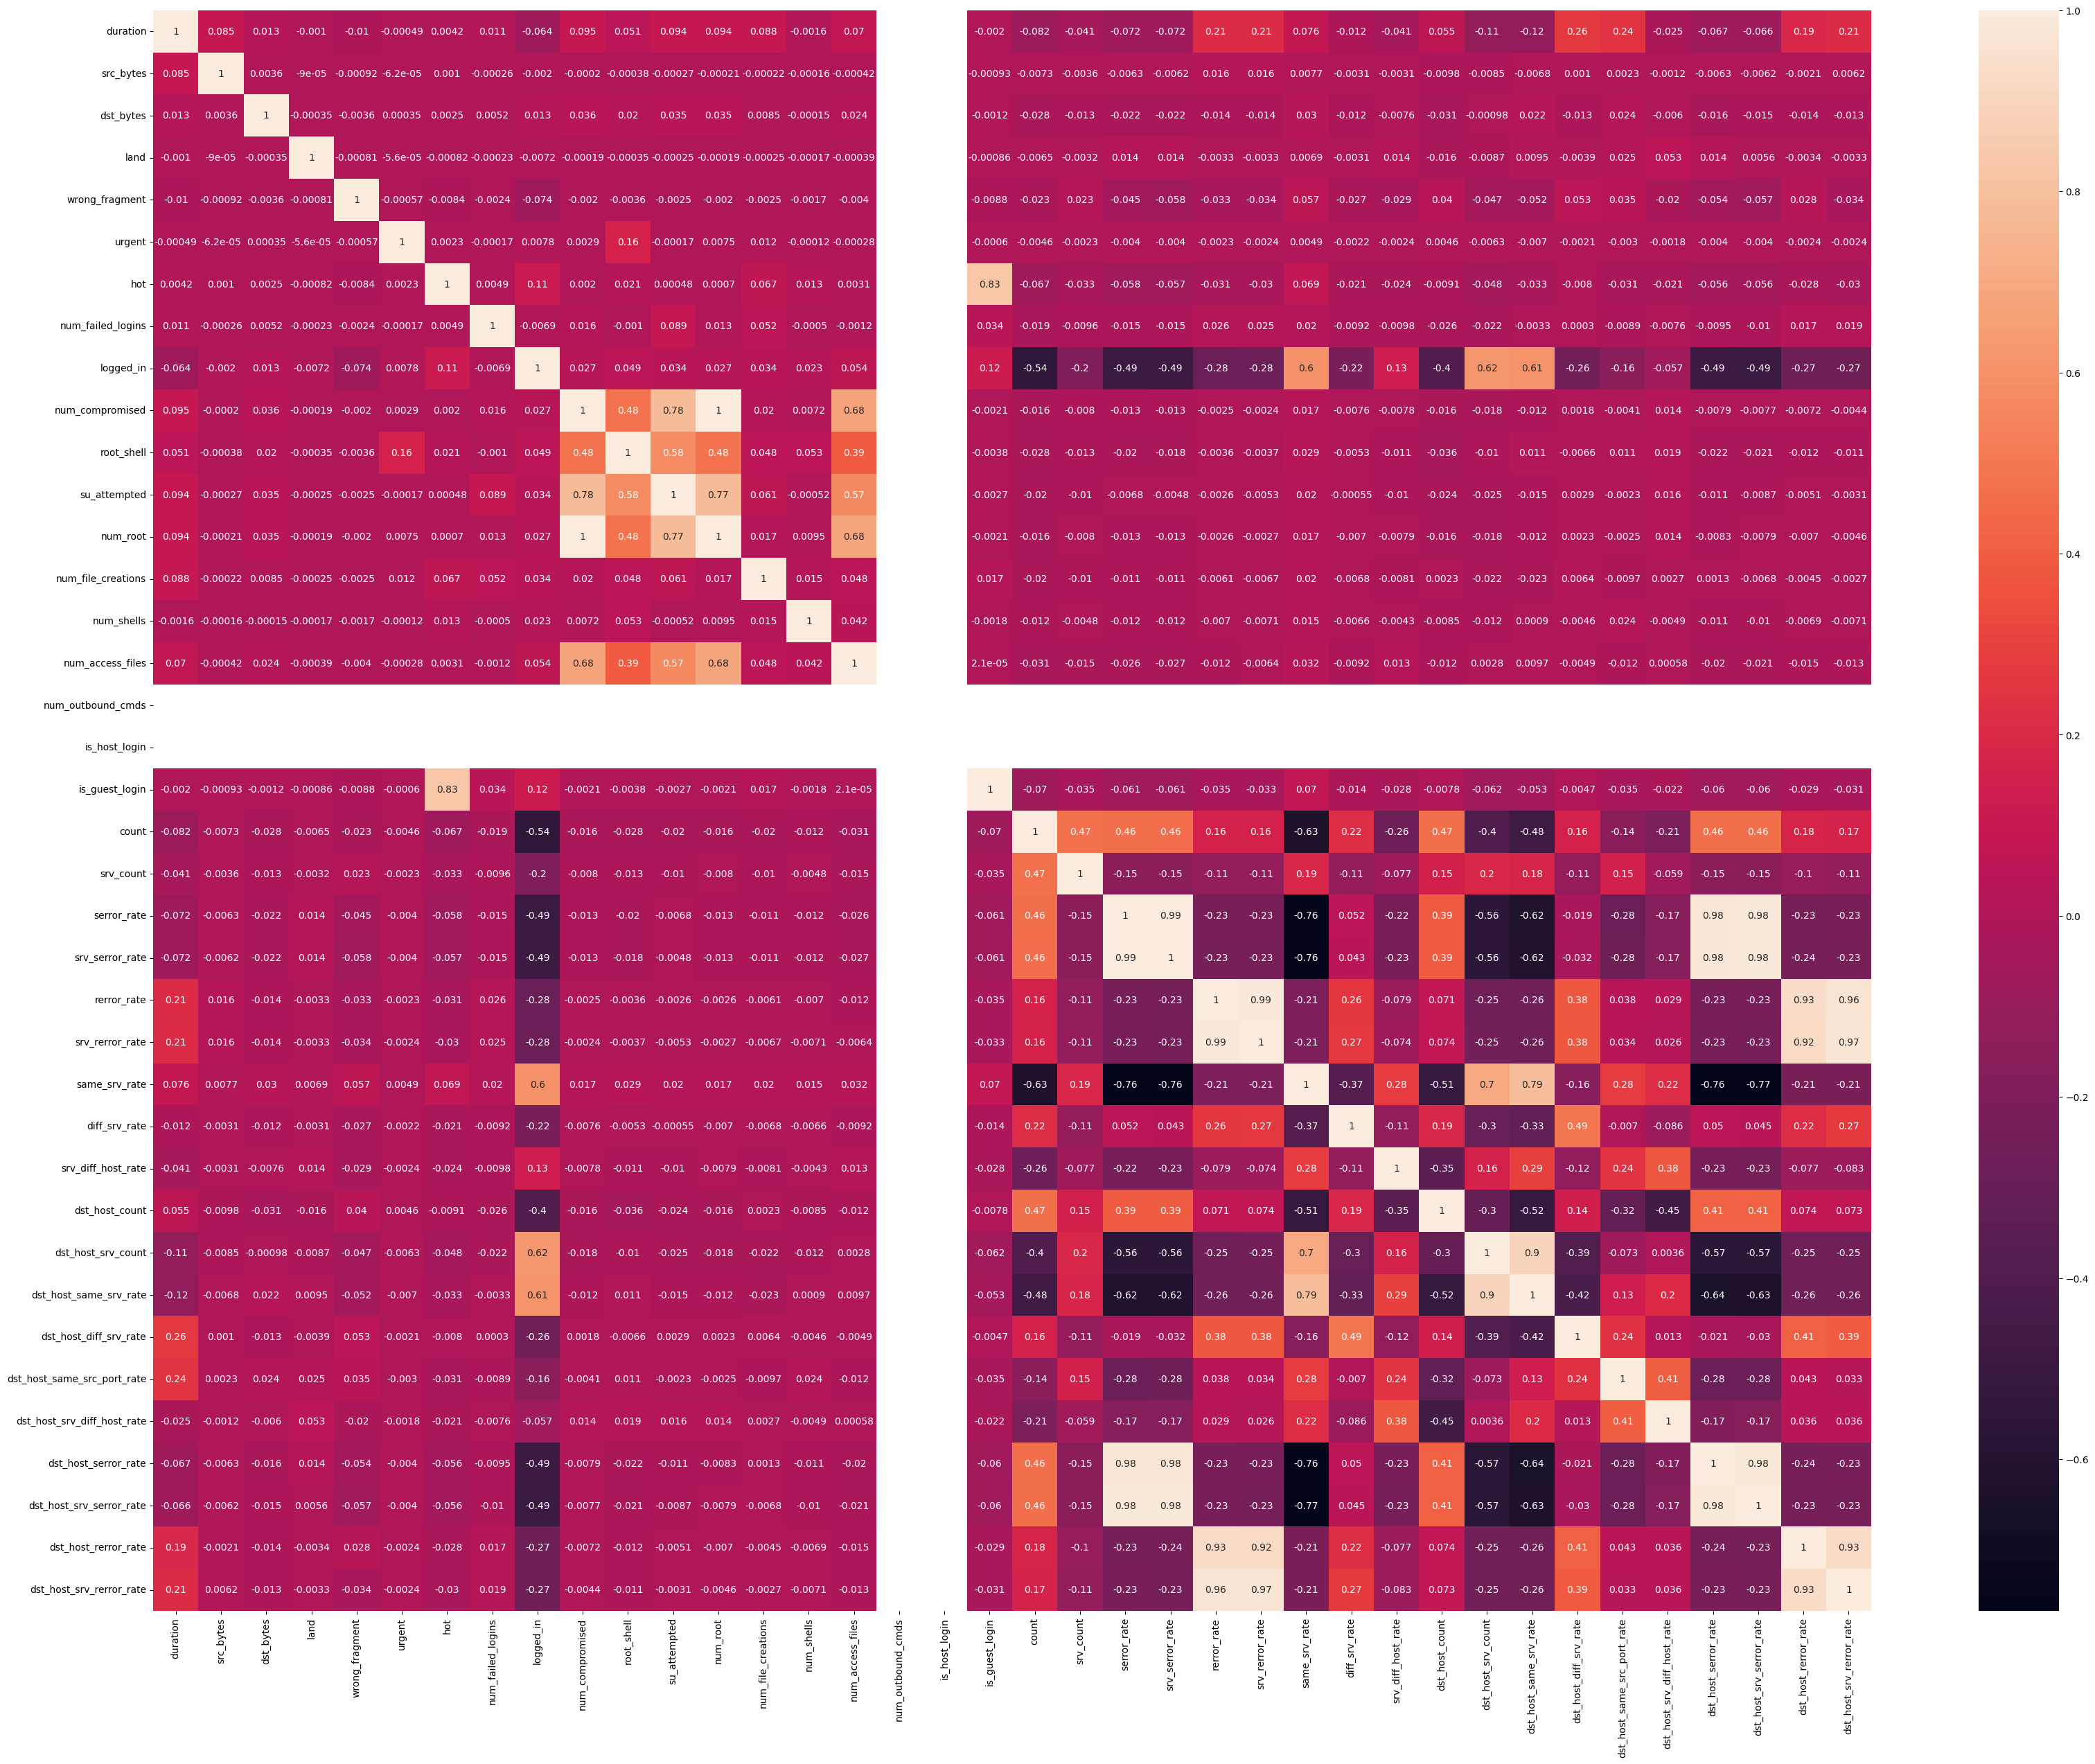

In [47]:
plt.figure(figsize=(40,30))
sb.heatmap(train_df.corr(numeric_only=True), annot=True)

<Axes: xlabel='class', ylabel='count'>

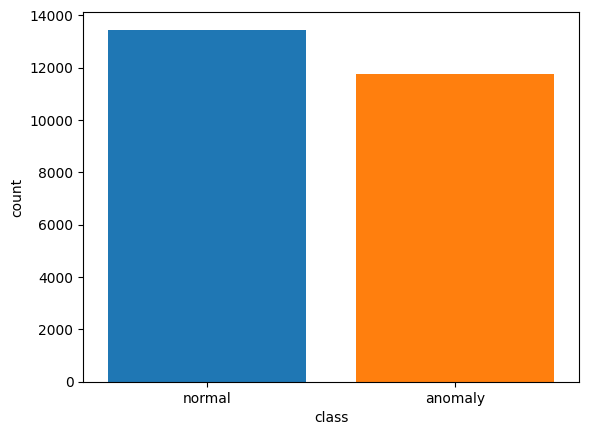

In [48]:
sb.countplot(x=train_df['class'], hue=train_df['class'], saturation=1,)

<h1>Label Encoding</h1>

In [49]:
def encoding(df): # Converting data into numerical values for modeling 
    for col in df.columns: # Looping through columns in dataframe
        if df[col].dtype == 'object': # Checking for categorial values within column
            label_encoder = LabelEncoder() 
            df[col] = label_encoder.fit_transform(df[col]) # Encoding column to numerical values

encoding(train_df)
encoding(test_df)

In [50]:
train_df.drop(['num_outbound_cmds'], axis=1, inplace=True)
test_df.drop(['num_outbound_cmds'], axis=1, inplace=True)

train_df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,class
0,0,1,19,9,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,1
1,0,2,41,9,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,1
2,0,1,46,5,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,0
3,0,1,22,9,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,1
4,0,1,22,9,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1


Data successfully converted to numerical values.

<h1>Feature Selection</h1>

In [51]:
X_train = train_df.drop(['class'], axis=1)
Y_train = train_df['class']

In [52]:
rfc = RandomForestClassifier()

rfe = RFE(rfc, n_features_to_select=10) # Using random forest classifier as the estimator to select 10 features
rfe = rfe.fit(X_train, Y_train) # fitting the test and train dataframes with recursive feature selection

feature_map = [(i, v) for i, v in itertools.zip_longest(rfe.get_support(), X_train.columns)] # Generating feature map array using features from rfe
selected_features = [v for i, v in feature_map if i==True] # Generating array of selected features from feature_map

selected_features

['protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'count',
 'same_srv_rate',
 'diff_srv_rate',
 'dst_host_srv_count',
 'dst_host_same_srv_rate']

In [53]:
X_train = X_train[selected_features]
print(X_train)

       protocol_type  service  flag  src_bytes  dst_bytes  count  \
0                  1       19     9        491          0      2   
1                  2       41     9        146          0     13   
2                  1       46     5          0          0    123   
3                  1       22     9        232       8153      5   
4                  1       22     9        199        420     30   
...              ...      ...   ...        ...        ...    ...   
25187              1       16     2          0          0    100   
25188              1       19     9        334          0      1   
25189              1       46     1          0          0    105   
25190              1       38     5          0          0    129   
25191              1       17     5          0          0     38   

       same_srv_rate  diff_srv_rate  dst_host_srv_count  \
0               1.00           0.00                  25   
1               0.08           0.15                   1   
2     

<h1>Scaling Data</h1>

In [54]:
import pickle

scaler = StandardScaler() # Used to standardize values by scaling with zero mean and unit variance to diminsh bias when model fitting
X_train = scaler.fit_transform(X_train) 
#test = scaler.fit_transform(test_df)

print(X_train)

scaler_file = "../models/vigil_scaler.pkl"
pickle.dump(scaler, open(scaler_file, 'wb'))

[[-0.12606067 -0.64538418  0.75302096 ... -0.34928194 -0.81398452
  -0.7791569 ]
 [ 2.21591606  0.76892549  0.75302096 ...  0.49083556 -1.03089514
  -1.15783086]
 [-0.12606067  1.09035951 -0.73992391 ...  0.04277289 -0.80494658
  -0.93508147]
 ...
 [-0.12606067  1.09035951 -2.23286879 ...  0.04277289 -0.92243983
  -1.04645617]
 [-0.12606067  0.57606508 -0.73992391 ... -0.01323494 -0.85917423
  -0.97963135]
 [-0.12606067 -0.77395779 -0.73992391 ...  0.26680423 -0.59707391
  -0.73460702]]


In [55]:
x_train, x_test, y_train, y_test = train_test_split(X_train, Y_train, train_size=0.70, random_state=1)
# Splitting train and test data with train_size = 70% and test_size = 30%

<h1>Random Forest Classifier</h1>

In [56]:
# Using Optuna for the optimization process of the model
def objective(trial): # Used to assist in defining the search space for the Random Forest Classifier hyperparameters
    rf_max_depth = trial.suggest_int('rf_max_depth', 2, 32, log=False) # Suggesting rf_max_depth between 2 and 32
    rf_max_features = trial.suggest_int('rf_max_features', 2, 10, log=False) # Suggesting rf_max_features between 2 and 10
    rf_n_estimators = trial.suggest_int('rf_n_estimators', 3, 20, log=False) # Suggesting rf_n_estimators between 3 and 20
    classifier_obj = RandomForestClassifier(max_features=rf_max_features, max_depth=rf_max_depth, n_estimators=rf_n_estimators) # Creating model with suggested hyperparameters
    classifier_obj.fit(x_train, y_train) # Fitting the model
    accuracy = classifier_obj.score(x_test, y_test)
    return accuracy # Displaying the accuracy of the model

In [57]:
# Finalizing optimization process
study_rf = optuna.create_study(direction='maximize') # Creating a study to keep track of trial history
study_rf.optimize(objective, n_trials=100) # Running 30 trials with the objective function
print(study_rf.best_trial) # Dispay the best trial with accuracy, values, and selected hyperparameters

[I 2024-09-22 18:34:31,503] A new study created in memory with name: no-name-90ed402a-1e10-426b-aad6-59d767e69d52
[I 2024-09-22 18:34:31,600] Trial 0 finished with value: 0.9933844932521831 and parameters: {'rf_max_depth': 30, 'rf_max_features': 10, 'rf_n_estimators': 4}. Best is trial 0 with value: 0.9933844932521831.
[I 2024-09-22 18:34:31,621] Trial 1 finished with value: 0.980815030431331 and parameters: {'rf_max_depth': 5, 'rf_max_features': 2, 'rf_n_estimators': 6}. Best is trial 0 with value: 0.9933844932521831.
[I 2024-09-22 18:34:31,686] Trial 2 finished with value: 0.9966922466260916 and parameters: {'rf_max_depth': 18, 'rf_max_features': 2, 'rf_n_estimators': 14}. Best is trial 2 with value: 0.9966922466260916.
[I 2024-09-22 18:34:31,785] Trial 3 finished with value: 0.9962953162212226 and parameters: {'rf_max_depth': 17, 'rf_max_features': 8, 'rf_n_estimators': 8}. Best is trial 2 with value: 0.9966922466260916.
[I 2024-09-22 18:34:31,836] Trial 4 finished with value: 0.967

FrozenTrial(number=67, state=TrialState.COMPLETE, values=[0.9978830378406987], datetime_start=datetime.datetime(2024, 9, 22, 18, 34, 38, 714212), datetime_complete=datetime.datetime(2024, 9, 22, 18, 34, 38, 839524), params={'rf_max_depth': 17, 'rf_max_features': 6, 'rf_n_estimators': 13}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'rf_max_depth': IntDistribution(high=32, log=False, low=2, step=1), 'rf_max_features': IntDistribution(high=10, log=False, low=2, step=1), 'rf_n_estimators': IntDistribution(high=20, log=False, low=3, step=1)}, trial_id=67, value=None)


Optimized Trial: <br><br>
Accuracy: .99682 <br>
Parameters: ['rf_max_depth': 14, 'rf_max_features': 5, 'rf_n_estimators': 15]
<br><br>
Accuracy: .99735 <br>
Parameters: ['rf_max_depth': 20, 'rf_max_features': 6, 'rf_n_estimators': 18]
<br><br>
Accuracy: .99788 <br>
Parameters: ['rf_max_depth': 17, 'rf_max_features': 6, 'rf_n_estimators': 13]

<h3>Fitting & Accuracy</h3>

In [80]:
rf = RandomForestClassifier(max_features = study_rf.best_trial.params['rf_max_features'], max_depth = study_rf.best_trial.params['rf_max_depth'], n_estimators = study_rf.best_trial.params['rf_n_estimators'])
rf.fit(x_train, y_train)

y_pred = rf.predict(x_test)

rf_train, rf_test = rf.score(x_train, y_train), rf.score(x_test, y_test)

print(f"Train Score: {rf_train}")
print(f"Test Score: {rf_test}")

print(f"\nConfusion Matrix: \n{confusion_matrix(y_test, y_pred)}")
print(f"\nClassification Report: \n{classification_report(y_test, y_pred, output_dict=True)}")

Train Score: 0.9998865827378927
Test Score: 0.9974861074358295

Confusion Matrix: 
[[3493   14]
 [   5 4046]]

Classification Report: 
{'0': {'precision': 0.998570611778159, 'recall': 0.9960079840319361, 'f1-score': 0.9972876516773732, 'support': 3507}, '1': {'precision': 0.996551724137931, 'recall': 0.9987657368550975, 'f1-score': 0.9976575021575638, 'support': 4051}, 'accuracy': 0.9974861074358295, 'macro avg': {'precision': 0.997561167958045, 'recall': 0.9973868604435168, 'f1-score': 0.9974725769174685, 'support': 7558}, 'weighted avg': {'precision': 0.9974885115094948, 'recall': 0.9974861074358295, 'f1-score': 0.9974858872284783, 'support': 7558}}


<Axes: >

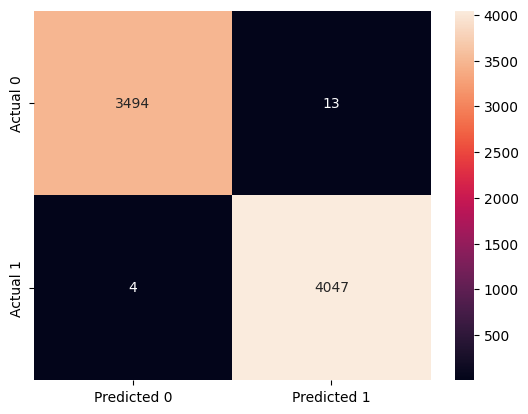

In [64]:
from sklearn.utils.multiclass import unique_labels

def plot_confusion_matrix(y_test, y_pred):
    labels = unique_labels(y_test)
    columns = [f'Predicted {label}'for label in labels]
    index = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_test, y_pred),
                         columns= columns, index = index)
    return sb.heatmap(table, annot=True, fmt='d')

plot_confusion_matrix(y_test, y_pred)

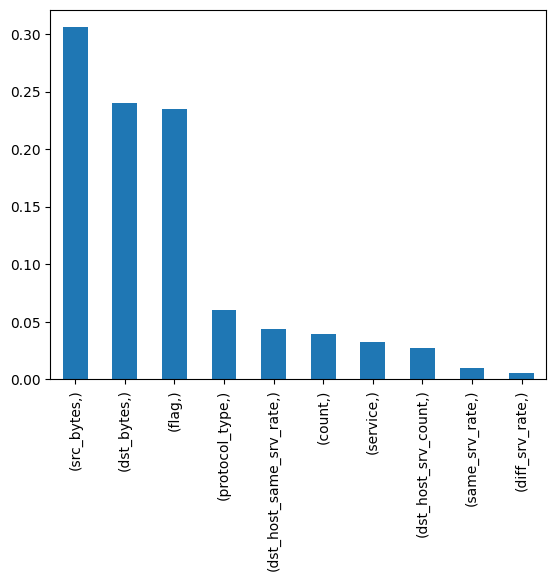

In [78]:
feature_importances = pd.Series(rf.feature_importances_, index=pd.DataFrame(selected_features)).sort_values(ascending=False)

# Plot a simple bar chart
feature_importances.plot.bar();

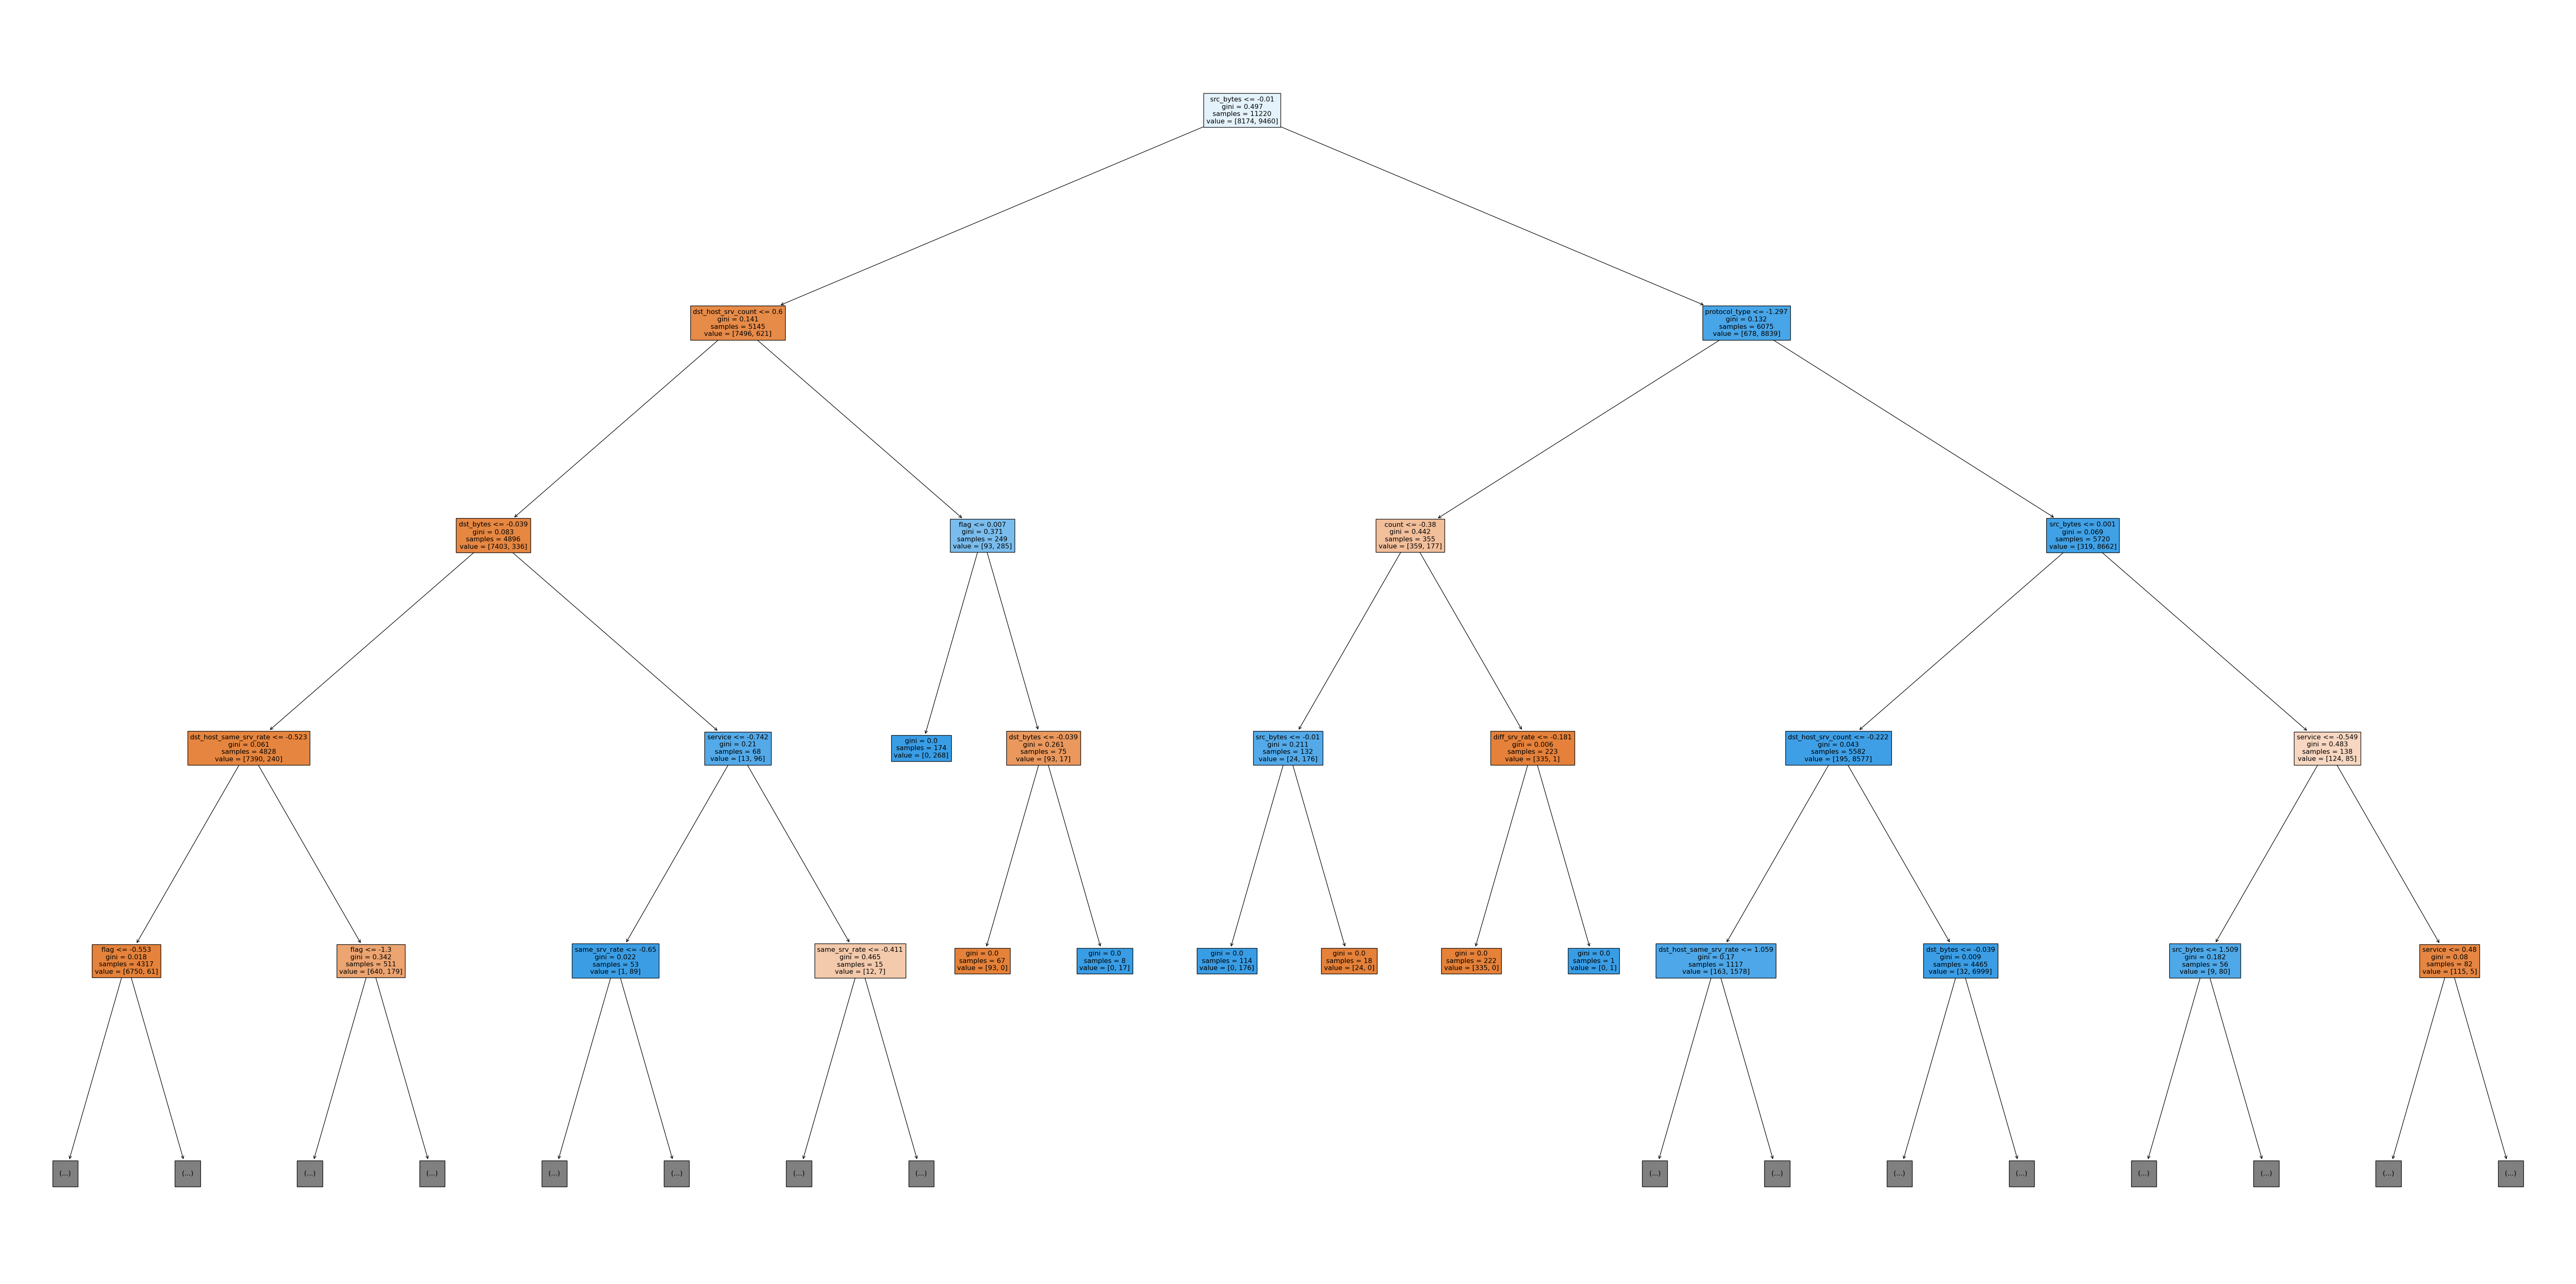

In [81]:
plt.figure(figsize=(80,40))
_= tree.plot_tree(rf.estimators_[0], 
                  feature_names=selected_features, 
                  max_depth=4,
                  filled=True)


<h1>Saving Model</h1>

In [33]:
import tarfile

model_file = "../models/vigil_model.pkl"
tar_file = "../models/vigil_model.tar.gz"

#pickle.dump(rf, open(model_file,'wb'))

#with tarfile.open(tar_file, mode='w:gz') as archive:
#    archive.add(model_file, arcname='vigil_model.pkl')

<h1>Verifying Model</h1>

In [34]:
loaded_model = pickle.load(open('../models/vigil_model.pkl','rb'))
print(loaded_model.predict(x_test[:5]))

[0 1 0 1 1]


In [35]:
np.set_printoptions(threshold = np.inf)
print(x_test)

[[-1.26060672e-01  1.09035951e+00 -7.39923913e-01 -1.00925239e-02
  -3.93097855e-02  1.39885913e+00 -1.41155246e+00  4.27728926e-02
  -9.58591598e-01 -1.06873111e+00]
 [-1.26060672e-01 -4.52523772e-01  7.53020960e-01 -9.95895592e-03
  -1.85578197e-03 -7.20243599e-01  7.72108662e-01 -3.49281943e-01
   1.26474221e+00  1.06966306e+00]
 [-1.26060672e-01  1.92608796e+00 -7.39923913e-01 -1.00925239e-02
  -3.93097855e-02  1.60815323e+00 -1.34331305e+00 -6.92427746e-02
  -8.59174232e-01 -9.79631349e-01]
 [-1.26060672e-01  1.41179353e+00  7.53020960e-01 -9.46948323e-03
  -3.54709471e-02 -7.11523012e-01 -7.51904827e-01  3.40324291e+00
   1.71151189e-01  8.95657340e-02]
 [-1.26060672e-01 -4.52523772e-01  7.53020960e-01 -9.94319324e-03
  -1.97440932e-02 -5.37111264e-01  7.72108662e-01 -3.49281943e-01
   1.26474221e+00  1.06966306e+00]
 [ 2.21591606e+00 -1.15967861e+00  7.53020960e-01 -1.00854722e-02
  -3.91184064e-02 -7.20243599e-01  7.72108662e-01 -3.49281943e-01
   5.05555054e-01  3.34590066e-01